In [1]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd

In [2]:
import geopandas as gpd
from shapely.ops import linemerge, polygonize, unary_union, nearest_points
from shapely.geometry import LineString, Point

box = gpd.read_file("/Users/cjense/Desktop/phd/Data/Termini/boundingbox3.shp").geometry.iloc[0]  # your purple box polygon
box_boundary = box.exterior

DataSourceError: /Users/cjense/Desktop/phd/Data/Termini/boundingbox3.shp: No such file or directory

In [10]:
Jensen_termini = gpd.read_file("/Users/cjense/Desktop/phd/Data/Termini/Jensen_traces_ZI_2.shp")
other_termini = gpd.read_file("/Users/cjense/Desktop/phd/Data/Termini/combined_termini_ZI.shp")

In [11]:
other_termini["Date"] = pd.to_datetime(other_termini["Date"], errors="coerce").combine_first(
    pd.to_datetime(other_termini["SourceDate"], errors="coerce").combine_first(
        pd.to_datetime(other_termini['Date_jense'], errors='coerce').combine_first(
            pd.to_datetime(other_termini['SourceDa_1'], errors='coerce')
        )
    )
)

other_termini = other_termini.set_crs("EPSG:4326", allow_override=True).to_crs(crs="EPSG:3413")
other_termini = other_termini.drop(columns=["SourceDate"])
Jensen_termini = Jensen_termini.set_crs("EPSG:4326", allow_override=True).to_crs(crs="EPSG:3413")
Jensen_termini['Date'] = pd.to_datetime(Jensen_termini['Date'])

In [12]:
termini = pd.concat([Jensen_termini, other_termini], axis=0, ignore_index=True)
termini = termini[termini['Date'] >= pd.Timestamp("2000-01-01")].reset_index(drop=True)
termini = termini.drop_duplicates(subset=['Date'], keep='first')
termini

,id,Date,ImagePath,SLCFlag,Satellite,Time,cloudShado,notes,otherImage,partialPic,...,Author,Center_X,Center_Y,Glacier__1,Path,SourceDa_1,Date_jense,Satellite_,layer_jens,path_1
0,2_0_0,2001-06-23,LANDSAT/LE07/C02/T1_RT_TOA/LE07_007003_20010623,0.0,LANDSAT_7,14:34:29.000,0.0,None,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
1,2_0_0,2005-06-11,LANDSAT/LE07/C02/T1_RT_TOA/LE07_006003_20050611,1.0,LANDSAT_7,14:28:21.000,0.0,None,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
2,2_0_0,2007-08-27,LANDSAT/LE07/C02/T1_RT_TOA/LE07_007003_20070827,1.0,LANDSAT_7,14:35:01.000,0.0,None,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
3,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_2_0_0,2015-08-21,LANDSAT/LC08/C02/T1_RT_TOA/LC08_011003_20150821,0.0,LANDSAT_8,15:09:33.000,0.0,None,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
4,1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_1_2_0_0,2015-09-08,LANDSAT/LC08/C02/T1_RT_TOA/LC08_009003_20150908,0.0,LANDSAT_8,14:57:18.000,0.0,None,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
750,NaN,2009-08-08,NaN,NaN,Landsat,NaN,NaN,None,NaN,NaN,...,PROMICE,-20.100811,78.891151,NaN,NaN,NaT,NaN,NaN,NaN,NaN
752,NaN,2016-09-14,NaN,NaN,Landsat,NaN,NaN,None,NaN,NaN,...,PROMICE,-20.774394,78.929051,NaN,NaN,NaT,NaN,NaN,NaN,NaN
753,NaN,2015-08-29,NaN,NaN,Landsat,NaN,NaN,None,NaN,NaN,...,PROMICE,-20.732735,78.944843,NaN,NaN,NaT,NaN,NaN,NaN,NaN
754,NaN,2010-06-25,NaN,NaN,Landsat,NaN,NaN,None,NaN,NaN,...,PROMICE,-20.118272,78.895483,NaN,NaN,NaT,NaN,NaN,NaN,NaN


In [13]:
gdf = gpd.GeoDataFrame(termini, crs="EPSG:3413", geometry=termini['geometry'])
gdf.to_file('/Users/cjense/Desktop/phd/Data/Termini/Jensen_and_othertraces_ZI_dropduplicates.shp', driver='ESRI Shapefile')

/Users/cjense/Desktop/phd/ZI 79N Seasonality/.pixi/envs/default/lib/python3.14/site-packages/pyogrio/raw.py:733: RuntimeWarning: Field Date created as String field, though DateTime requested.
  ogr_write(
/Users/cjense/Desktop/phd/ZI 79N Seasonality/.pixi/envs/default/lib/python3.14/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Path' to 'Path_1'
  ogr_write(
/Users/cjense/Desktop/phd/ZI 79N Seasonality/.pixi/envs/default/lib/python3.14/site-packages/pyogrio/raw.py:733: RuntimeWarning: Field SourceDa_1 created as String field, though DateTime requested.
  ogr_write(
/Users/cjense/Desktop/phd/ZI 79N Seasonality/.pixi/envs/default/lib/python3.14/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'path_1' to 'path_1_1'
  ogr_write(


[OK] 2000-06-22 00:00:00: 1423.239 km^2  -> /Users/cjense/Desktop/phd/Data/Termini/ZI/QC_plots/2000-06-22_00-00-00.png
[WARN] 2000-07-24 00:00:00: resulting polygon (1925.9 km^2) exceeds the 1750 km^2 sanity max -- treating as a failed split (likely the split didn't actually cut anything)
[OK] 2001-06-23 00:00:00: 1354.752 km^2  -> /Users/cjense/Desktop/phd/Data/Termini/ZI/QC_plots/2001-06-23_00-00-00.png
[OK] 2002-06-21 00:00:00: 1369.752 km^2  -> /Users/cjense/Desktop/phd/Data/Termini/ZI/QC_plots/2002-06-21_00-00-00.png
[OK] 2003-06-14 00:00:00: 1199.321 km^2  -> /Users/cjense/Desktop/phd/Data/Termini/ZI/QC_plots/2003-06-14_00-00-00.png
[WARN] 2003-07-31 00:00:00: resulting polygon (1926.0 km^2) exceeds the 1750 km^2 sanity max -- treating as a failed split (likely the split didn't actually cut anything)
[WARN] 2004-06-26 00:00:00: resulting polygon (1926.5 km^2) exceeds the 1750 km^2 sanity max -- treating as a failed split (likely the split didn't actually cut anything)
[OK] 2004-0

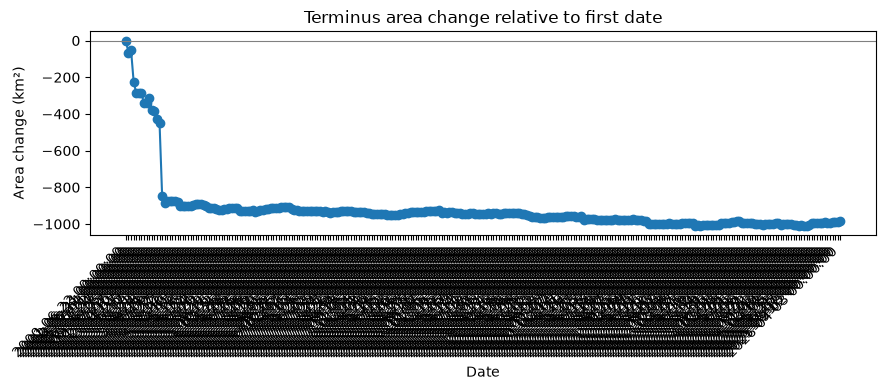

In [25]:
"""
Terminus area-change calculation with per-date polygon visualization.

v19 changes (from v18):
  - THE FIX: v18 applied the "reject full-box / oversized" area-sanity
    check (area <= 1500 km^2) at THREE different points that could
    disagree with each other:
        1. terminus_records (the 'termini' GPKG layer) appended
           whenever ice_poly was not None -- no area check at all.
        2. results/CSV/'ice_polygons' layer -- filtered AFTER the loop
           with area_m2 <= 1500e6.
        3. QC plots -- gated in-loop with area < 1500e6 (strict '<',
           not '<=', a second small inconsistency vs #2).
    A date whose ice_poly came back as (approximately) the whole box
    would therefore end up: written to 'termini', but NOT written to
    'ice_polygons'/CSV, and NOT plotted -- three different outcomes
    for the same date, which is exactly the "polygon/termini/CSV
    don't match, and some termini don't show up in the gpkg" problem.

    Fixed by computing the area-sanity check exactly ONCE, immediately
    after ice_poly is finalized (right after the resplit-recovery
    fallback), using a single AREA_SANITY_MAX_KM2 constant. If the
    resulting polygon exceeds that (i.e. the "split" didn't really cut
    anything -- classic full-box-returned failure), it is treated
    exactly like a no_split: ice_poly is nulled, the date is added to
    flagged_for_qc.gpkg with reason "area_exceeds_sanity_max", and
    n_warnings is incremented.

    A single boolean, `success`, then gates ALL THREE outputs for that
    date: records (-> CSV / 'ice_polygons' layer), terminus_records
    (-> 'termini' layer), and the QC plot. No separate/duplicate area
    filtering happens anywhere else -- the post-loop bulk filter on
    results that v18 had is removed entirely, since only successful
    dates are ever appended to records in the first place. This
    guarantees the CSV, both GPKG layers, and the plotted PNGs always
    describe exactly the same set of dates.

Everything else (tip trimming, precision snapping, long-gap fallback
to the last full-span boundary, manual box-ring-cut recovery for
no_split dates, same-date trace combining) is unchanged from v18.
"""

import os
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString, MultiLineString, Polygon
from shapely.ops import linemerge, polygonize, unary_union, nearest_points, substring
from shapely import set_precision

# ----------------------------- CONFIG ------------------------------
# TERMINI_PATH = "/Users/cjense/Desktop/phd/Data/Termini/Jensen_and_othertraces_ZI_cleaned_6.shp"
TERMINI_PATH = "/Users/cjense/Desktop/phd/Data/Termini/ZI/all_termini_ZI_cleaned.shp"
BOX_PATH = "/Users/cjense/Desktop/phd/Data/Termini/ZI/bbox_ZI.shp"
DATE_FIELD = "Date"

x_pt = 480900.158671
y_pt = -1098954.829477
ICE_REF_XY = (x_pt, y_pt)

# Discard candidate ice-side polygons smaller than this (m^2) -- filters
# out slivers created by self-intersections/overlap noise.
MIN_POLYGON_AREA = 1000

# Coordinate precision grid (meters) used to snap all geometries before
# noding/polygonizing. Must be coarse enough to absorb floating-point
# noise from repeated geometric ops, but far finer than any real
# feature you care about. 1 cm is a safe default for meter-scale data.
PRECISION_GRID = 0.01

# When trimming an outside tip back to the box, ignore any crossing
# that isn't followed by a genuinely stable "inside" run at least this
# long (map units, e.g. meters).
MIN_STABLE_RUN_LENGTH = 50

# If a free endpoint's connector to the box would be longer than this
# (meters), fall back to the most recent full-span boundary instead.
LONG_GAP_THRESHOLD = 500

# --- v19: single source of truth for the "is this area even real"
# sanity check. If ice_poly comes back bigger than this, the split
# didn't actually cut anything (classic full-box-returned failure) and
# the date is treated exactly like a no_split -- everywhere. Set this
# a bit below your box's true full area (this box is ~1926 km^2).
AREA_SANITY_MAX_KM2 = 1750
AREA_SANITY_MAX_M2 = AREA_SANITY_MAX_KM2 * 1e6

OUTPUT_DIR = "/Users/cjense/Desktop/phd/Data/Termini/ZI/QC_plots"
# ---------------------------------------------------------------------


def snap(geom):
    return set_precision(geom, PRECISION_GRID)


def extract_crossing_points(geom):
    if geom.is_empty:
        return []
    if geom.geom_type == "Point":
        return [geom]
    if geom.geom_type == "MultiPoint":
        return list(geom.geoms)
    if geom.geom_type == "GeometryCollection":
        pts = []
        for g in geom.geoms:
            pts.extend(extract_crossing_points(g))
        return pts
    if geom.geom_type == "LineString":
        return [Point(geom.coords[0]), Point(geom.coords[-1])]
    if geom.geom_type == "MultiLineString":
        pts = []
        for g in geom.geoms:
            pts.extend(extract_crossing_points(g))
        return pts
    return []


def compute_runs(line, box, crossing_dists):
    breakpoints = sorted(set([0.0] + list(crossing_dists) + [line.length]))
    runs = []
    for i in range(len(breakpoints) - 1):
        s, e = breakpoints[i], breakpoints[i + 1]
        if e - s < 1e-9:
            continue
        mid_pt = line.interpolate((s + e) / 2)
        runs.append((s, e, box.covers(mid_pt)))
    return runs


def trim_tips_to_box(line, box, min_stable_run):
    start_pt = Point(line.coords[0])
    end_pt = Point(line.coords[-1])

    crossings = line.intersection(box.exterior)
    pts = extract_crossing_points(crossings)
    dists = sorted(set(round(line.project(p), 6) for p in pts))
    runs = compute_runs(line, box, dists)

    new_start = 0.0
    new_end = line.length

    if not box.covers(start_pt):
        stable = next(
            (r for r in runs if r[2] and (r[1] - r[0]) >= min_stable_run), None
        )
        if stable is None:
            return None
        new_start = stable[0]

    if not box.covers(end_pt):
        stable = next(
            (r for r in reversed(runs) if r[2] and (r[1] - r[0]) >= min_stable_run),
            None,
        )
        if stable is None:
            return None
        new_end = stable[1]

    if new_start >= new_end:
        return None

    return substring(line, new_start, new_end)


def clip_to_box(geom, box):
    if geom.geom_type == "LineString":
        raw_parts = [geom]
    elif geom.geom_type == "MultiLineString":
        raw_parts = list(geom.geoms)
    else:
        raw_parts = []

    trimmed = []
    for part in raw_parts:
        t = trim_tips_to_box(part, box, MIN_STABLE_RUN_LENGTH)
        if t is not None and not t.is_empty:
            trimmed.append(t)

    if not trimmed:
        return LineString()
    if len(trimmed) == 1:
        return trimmed[0]
    return MultiLineString(trimmed)


def get_parts(geom):
    if geom.is_empty:
        return []
    if geom.geom_type == "LineString":
        lines = [geom]
    elif geom.geom_type == "MultiLineString":
        lines = list(geom.geoms)
    elif geom.geom_type == "GeometryCollection":
        lines = []
        for g in geom.geoms:
            if g.geom_type == "LineString":
                lines.append(g)
            elif g.geom_type == "MultiLineString":
                lines.extend(list(g.geoms))
    else:
        lines = []

    if not lines:
        return []

    merged = linemerge(lines) if len(lines) > 1 else lines[0]
    if merged.geom_type == "MultiLineString":
        return list(merged.geoms)
    return [merged]


def trim_ref_line_from_point(ref_line, cut_pt, toward_pt):
    line = ref_line
    if line.geom_type == "MultiLineString":
        merged = linemerge(line)
        line = merged if merged.geom_type == "LineString" else line

    if line.geom_type == "MultiLineString":
        comp = min(line.geoms, key=lambda g: g.distance(cut_pt))
    elif line.geom_type == "LineString":
        comp = line
    else:
        return None

    if comp.is_empty or len(comp.coords) < 2:
        return None

    d_cut = comp.project(cut_pt)
    end_a = Point(comp.coords[0])
    end_b = Point(comp.coords[-1])
    d_end = 0.0 if toward_pt.distance(end_a) <= toward_pt.distance(end_b) else comp.length

    lo, hi = sorted([d_cut, d_end])
    if hi - lo < 1e-9:
        return None
    return substring(comp, lo, hi)


def build_connectors(parts, box_boundary, prev_ref_line, long_gap_threshold):
    connectors = []
    prev_ref_segments = []

    for part in parts:
        for pt in (Point(part.coords[0]), Point(part.coords[-1])):
            if pt.distance(box_boundary) < 1e-6:
                continue

            _, box_pt = nearest_points(pt, box_boundary)
            box_dist = pt.distance(box_pt)

            target_pt = box_pt
            if box_dist > long_gap_threshold and prev_ref_line is not None:
                _, prev_pt = nearest_points(pt, prev_ref_line)
                prev_dist = pt.distance(prev_pt)
                if prev_dist < long_gap_threshold:
                    target_pt = prev_pt
                    seg = trim_ref_line_from_point(prev_ref_line, prev_pt, pt)
                    if seg is not None and not seg.is_empty:
                        prev_ref_segments.append(seg)

            connectors.append(LineString([pt, target_pt]))

    return connectors, prev_ref_segments


def close_terminus(trace_geom, box, box_boundary_snapped, ice_ref_pt_snapped, min_area,
                    prev_ref_line=None, long_gap_threshold=LONG_GAP_THRESHOLD):
    clipped = clip_to_box(trace_geom, box)
    parts = get_parts(clipped)
    if not parts:
        return None, [], [], 0, False, []

    connectors, prev_ref_segments = build_connectors(
        parts, box_boundary_snapped, prev_ref_line, long_gap_threshold
    )
    used_prev_ref = len(prev_ref_segments) > 0

    all_lines = [snap(p) for p in parts] + [snap(c) for c in connectors] + [box_boundary_snapped]
    for seg in prev_ref_segments:
        all_lines.append(snap(seg))

    noded = unary_union(all_lines)
    polys = list(polygonize(noded))

    ice_polys = [p for p in polys if p.area >= min_area and p.contains(ice_ref_pt_snapped)]
    ice_poly = unary_union(ice_polys) if ice_polys else None

    return ice_poly, parts, connectors, len(polys), used_prev_ref, prev_ref_segments


def _split_ring_at_distances(ring, d1, d2):
    lo, hi = sorted([d1, d2])
    arc_a = substring(ring, lo, hi)

    tail = substring(ring, hi, ring.length)
    head = substring(ring, 0.0, lo)
    tail_coords = list(tail.coords) if not tail.is_empty else []
    head_coords = list(head.coords) if not head.is_empty else []
    if tail_coords and head_coords:
        wrap_coords = tail_coords[:-1] + head_coords
    else:
        wrap_coords = tail_coords or head_coords
    arc_b = LineString(wrap_coords)

    return arc_a, arc_b


def split_box_with_line(box, cut_line, ice_ref_pt, min_area):
    ring = box.exterior
    p_start = Point(cut_line.coords[0])
    p_end = Point(cut_line.coords[-1])

    d_start = ring.project(p_start)
    d_end = ring.project(p_end)

    if abs(d_start - d_end) < 1e-6:
        return None

    ring_pt_start = ring.interpolate(d_start)
    ring_pt_end = ring.interpolate(d_end)

    forced_cut_coords = (
        [tuple(ring_pt_start.coords)[0]]
        + list(cut_line.coords)[1:-1]
        + [tuple(ring_pt_end.coords)[0]]
    )

    arc_1, arc_2 = _split_ring_at_distances(ring, d_start, d_end)

    def orient(arc):
        if arc.is_empty or len(arc.coords) < 2:
            return None
        head, tail = Point(arc.coords[0]), Point(arc.coords[-1])
        if head.distance(ring_pt_start) <= tail.distance(ring_pt_start):
            return list(arc.coords)
        return list(arc.coords)[::-1]

    def make_poly(arc):
        arc_coords = orient(arc)
        if arc_coords is None:
            return None
        coords = arc_coords + list(reversed(forced_cut_coords))[1:]
        try:
            poly = Polygon(coords)
        except Exception:
            return None
        if poly.is_empty:
            return None
        if not poly.is_valid:
            poly = poly.buffer(0)
        return poly

    candidates = [make_poly(arc_1), make_poly(arc_2)]
    candidates = [p for p in candidates if p is not None and not p.is_empty and p.area >= min_area]
    ice_candidates = [p for p in candidates if p.contains(ice_ref_pt)]
    if not ice_candidates:
        return None
    return unary_union(ice_candidates) if len(ice_candidates) > 1 else ice_candidates[0]


def resplit_flagged_date(trace_geom, box, ice_ref_pt, min_area, prev_ref_line, long_gap_threshold):
    clipped = clip_to_box(trace_geom, box)
    parts = get_parts(clipped)
    if not parts:
        return None

    connectors, prev_ref_segments = build_connectors(
        parts, snap(box.exterior), prev_ref_line, long_gap_threshold
    )
    if prev_ref_segments:
        return None

    cut_line = linemerge(list(parts) + list(connectors))
    if cut_line.geom_type != "LineString":
        return None

    return split_box_with_line(box, cut_line, ice_ref_pt, min_area)


def plot_date(date_label, box, parts, connectors, ice_poly, ice_ref_pt, out_path,
              flag_warning, prev_ref_segments=None, recovered=False):
    fig, ax = plt.subplots(figsize=(8, 8))

    gpd.GeoSeries([box]).boundary.plot(ax=ax, color="purple", linewidth=1.2, label="Box")

    if ice_poly is not None:
        gpd.GeoSeries([ice_poly]).plot(ax=ax, color="lightblue", alpha=0.5, edgecolor="none")

    if prev_ref_segments:
        for k, seg in enumerate(prev_ref_segments):
            gpd.GeoSeries([seg]).plot(
                ax=ax, color="orange", linewidth=1.5, linestyle=":",
                label="Previous boundary (trimmed, used for a long gap)" if k == 0 else None
            )

    for k, part in enumerate(parts):
        gpd.GeoSeries([part]).plot(
            ax=ax, color="crimson", linewidth=2,
            label="Terminus trace" if k == 0 else None
        )

    for k, conn in enumerate(connectors):
        gpd.GeoSeries([conn]).plot(
            ax=ax, color="black", linewidth=1.2, linestyle="--",
            label="Snap connector" if k == 0 else None
        )

    ax.plot(*ice_ref_pt.coords[0], marker="*", color="gold",
            markersize=14, markeredgecolor="black", label="Ice-side ref pt")

    area_km2 = ice_poly.area / 1e6 if ice_poly is not None else float("nan")
    title = f"{date_label} — area = {area_km2:.3f} km²"
    title_color = "black"
    if recovered:
        title = "[fixed via manual box-cut] " + title
        title_color = "darkorange"
    if flag_warning:
        title = "[!] NO SPLIT — " + title
        title_color = "red"
    ax.set_title(title, color=title_color)
    ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.close(fig)


def load_and_prepare_termini(path, date_field):
    termini = gpd.read_file(path)
    termini[date_field] = pd.to_datetime(termini[date_field], errors="coerce")
    termini = termini[
        termini[date_field].notna() & (termini[date_field] >= pd.Timestamp("2000-01-01"))
    ].reset_index(drop=True)
    return termini


def resolve_same_date_traces(termini, date_field):
    kept_rows = []
    for date_key, group in termini.groupby(date_field, sort=False):
        geoms = list(group.geometry)
        if len(geoms) == 1:
            kept_rows.append(group.iloc[0])
            continue
        print(f"[INFO] {date_key}: {len(geoms)} traces -- "
              f"combining into a single boundary, one area for the date")
        combined_row = group.iloc[0].copy()
        combined_row.geometry = unary_union(geoms)
        kept_rows.append(combined_row)
    return gpd.GeoDataFrame(kept_rows, crs=termini.crs).reset_index(drop=True)


def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    termini = load_and_prepare_termini(TERMINI_PATH, DATE_FIELD)
    termini = resolve_same_date_traces(termini, DATE_FIELD)
    termini = termini.sort_values(DATE_FIELD).reset_index(drop=True)

    box = gpd.read_file(BOX_PATH).geometry.iloc[0]
    box_boundary_snapped = snap(box.exterior)
    ice_ref_pt_snapped = snap(Point(*ICE_REF_XY))
    ice_ref_pt_plot = Point(*ICE_REF_XY)

    records = []
    terminus_records = []
    n_warnings = 0
    n_used_prev_ref = 0
    n_recovered = 0
    n_area_rejected = 0
    flagged_records = []

    full_span_ref_line = None

    for _, row in termini.iterrows():
        date_label = str(row[DATE_FIELD])
        ref_line_used = full_span_ref_line
        ice_poly, parts, connectors, n_polys, used_prev_ref, prev_ref_segments = close_terminus(
            row.geometry, box, box_boundary_snapped, ice_ref_pt_snapped, MIN_POLYGON_AREA,
            prev_ref_line=ref_line_used, long_gap_threshold=LONG_GAP_THRESHOLD
        )

        flag_reasons = []
        recovered = False

        if used_prev_ref:
            n_used_prev_ref += 1
            flag_reasons.append("partial_span")
            print(f"[INFO] {date_label}: a gap exceeded {LONG_GAP_THRESHOLD} m -- "
                  f"snapped to the most recent full-span boundary instead of the box")

        flag_warning = (n_polys <= 1)
        if flag_warning:
            fallback_poly = resplit_flagged_date(
                row.geometry, box, ice_ref_pt_plot, MIN_POLYGON_AREA,
                ref_line_used, LONG_GAP_THRESHOLD
            )
            if fallback_poly is not None:
                ice_poly = fallback_poly
                flag_warning = False
                recovered = True
                n_recovered += 1
                flag_reasons.append("resplit_recovered")
                print(f"[FIXED] {date_label}: recovered a valid split via manual box-ring cut")
            else:
                n_warnings += 1
                flag_reasons.append("no_split")
                print(f"[WARN] {date_label}: polygonize produced only {n_polys} polygon(s) and "
                      f"the manual box-cut fallback couldn't resolve it -- check this date manually")
                ice_poly = None

        # --- v19: SINGLE area-sanity check, applied once, right here.
        # Anything that "split" but came back at/near the full box area
        # is not a real cut -- treat it exactly like a no_split, so it
        # never diverges between the CSV, the two GPKG layers, and the
        # plotted PNGs.
        if ice_poly is not None and ice_poly.area > AREA_SANITY_MAX_M2:
            n_warnings += 1
            n_area_rejected += 1
            flag_reasons.append("area_exceeds_sanity_max")
            print(f"[WARN] {date_label}: resulting polygon ({ice_poly.area/1e6:.1f} km^2) "
                  f"exceeds the {AREA_SANITY_MAX_KM2} km^2 sanity max -- treating as a failed "
                  f"split (likely the split didn't actually cut anything)")
            ice_poly = None
            flag_warning = True
            recovered = False

        # --- v19: ONE success flag gates records, terminus_records, and
        # the plot -- no separate/duplicate area filtering anywhere else.
        success = ice_poly is not None

        if flag_reasons:
            flagged_records.append({
                "date": date_label,
                "flag_reason": ";".join(flag_reasons),
                "geometry": row.geometry,
            })

        if success:
            area = ice_poly.area

            terminus_geom = unary_union(list(parts) + list(connectors) + list(prev_ref_segments))
            terminus_records.append({
                "date": date_label,
                "completed_from_previous": used_prev_ref,
                "geometry": terminus_geom,
            })

            records.append({"date": date_label, "area_m2": area, "geometry": ice_poly})

            # only promote to the full-span reference if this date closed
            # cleanly on its own (no gap fallback needed)
            if not used_prev_ref:
                full_span_ref_line = unary_union(
                    [snap(p) for p in parts] + [snap(c) for c in connectors]
                )

            safe_label = date_label.replace(":", "-").replace(" ", "_")
            out_path = os.path.join(OUTPUT_DIR, f"{safe_label}.png")
            plot_date(date_label, box, parts, connectors, ice_poly, ice_ref_pt_plot, out_path,
                      flag_warning=False, prev_ref_segments=prev_ref_segments,
                      recovered=recovered)
            print(f"[OK] {date_label}: {area/1e6:.3f} km^2  -> {out_path}")

    if not records:
        raise ValueError("No valid polygon areas found; cannot compute area change.")

    results = gpd.GeoDataFrame(records, crs=termini.crs)
    results["area_km2"] = results["area_m2"] / 1e6
    ref_area = results["area_km2"].iloc[0]
    results["area_change_km2"] = results["area_km2"] - ref_area

    results.drop(columns="geometry").to_csv("/Users/cjense/Desktop/phd/data/termini/ZI/terminus_area_change.csv", index=False)
    results.to_file("/Users/cjense/Desktop/phd/data/termini/ZI/terminus_area_change_polygons_ZI.gpkg", layer="ice_polygons", driver="GPKG")

    terminus_gdf = gpd.GeoDataFrame(terminus_records, crs=termini.crs)
    terminus_gdf.to_file("/Users/cjense/Desktop/phd/data/termini/ZI/terminus_area_change_polygons.gpkg", layer="termini", driver="GPKG")
    n_completed = int(terminus_gdf["completed_from_previous"].sum())
    print(f"\n{len(terminus_gdf)} terminus feature(s) written -> "
          f"terminus_area_change_polygons.gpkg (layer 'termini'), "
          f"{n_completed} completed using a previous boundary")
    print(f"(matches: {len(results)} row(s) in CSV / 'ice_polygons', "
          f"{len(terminus_gdf)} in 'termini' -- these now always agree)")

    if flagged_records:
        flagged_gdf = gpd.GeoDataFrame(flagged_records, crs=termini.crs)
        flagged_gdf.to_file("/Users/cjense/Desktop/phd/data/termini/ZI/flagged_for_qc.gpkg", driver="GPKG")
        print(f"\n{len(flagged_gdf)} feature(s) flagged/audited -> flagged_for_qc.gpkg")
        print(flagged_gdf["flag_reason"].value_counts().to_string())
    else:
        print("\nNo dates were flagged -- nothing written to flagged_for_qc.gpkg")

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(results["date"], results["area_change_km2"], marker="o")
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_ylabel("Area change (km²)")
    ax.set_xlabel("Date")
    ax.set_title("Terminus area change relative to first date")
    plt.xticks(rotation=45, ha="right")
    fig.tight_layout()
    fig.savefig("/Users/cjense/Desktop/phd/data/termini/ZI/terminus_area_change_timeseries.png", dpi=150)

    print(f"\nDone. {n_warnings} date(s) unresolved/rejected "
          f"({n_area_rejected} of those for exceeding the area sanity max).")
    print(f"{n_recovered} date(s) recovered via the manual box-ring-cut fallback -- worth a quick visual check.")
    print(f"{n_used_prev_ref} date(s) used the full-span-reference fallback for a long gap.")
    print("Per-date QC plots in:", OUTPUT_DIR)


if __name__ == "__main__":
    main()

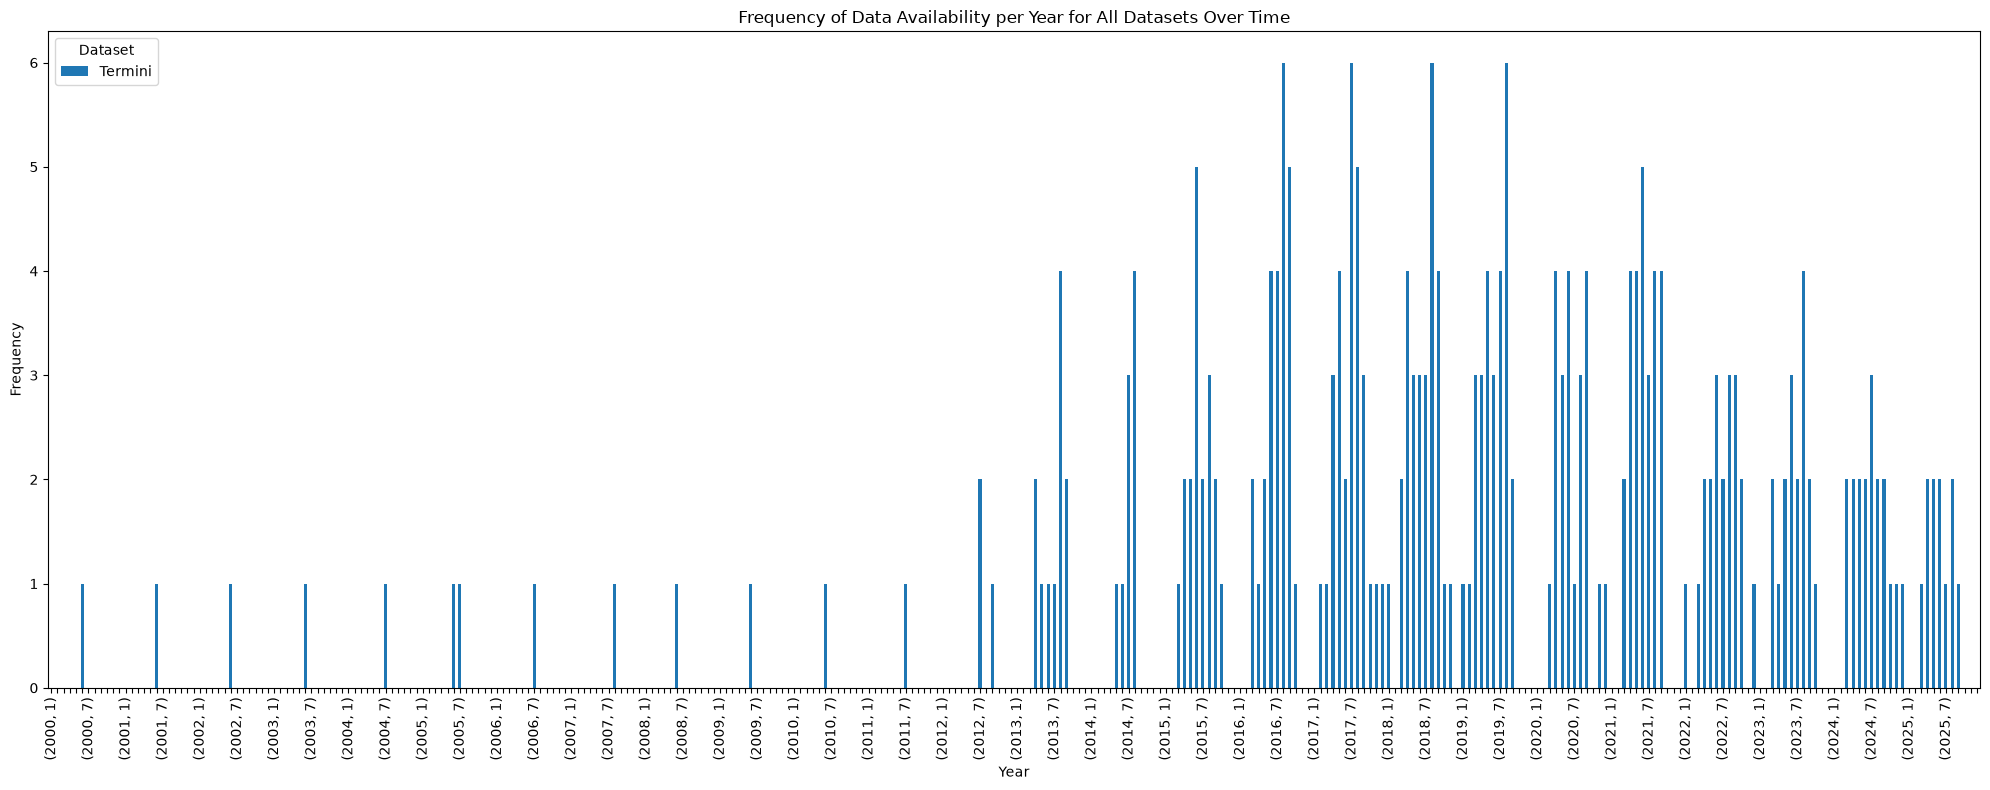

In [ ]:
result = gpd.read_file("/Users/cjense/Desktop/phd/data/termini/ZI/terminus_area_change_polygons_ZI.gpkg")
# Group each dataset by Year and Month and count occurrences
# nsidc_counts = zach_nsidc.groupby(['Year', 'Month']).size().rename('NSIDC')
# # autoterm_counts = zach_autoterm.groupby(['Year', 'Month']).size().rename('AutoTerm')
# termpicks_counts = zach_termpicks.groupby(['Year', 'Month']).size().rename('TermPicks')
# sofia_counts = sofia_termini.groupby(['Year', 'Month']).size().rename('Sofia Termini')

result['Year'] = pd.to_datetime(result['date']).dt.year
result['Month'] = pd.to_datetime(result['date']).dt.month
jensen_counts = result.groupby(['Year', 'Month']).size().rename('Termini')

# Create a complete index of all Year and Month combinations from 2000 to 2024
all_years_months = pd.MultiIndex.from_product(
    [range(2000, 2026), range(1, 13)], names=["Year", "Month"]
)

# Reindex each dataset to include all Year and Month combinations, filling missing values with 0
# nsidc_counts = nsidc_counts.reindex(all_years_months, fill_value=0)
# # autoterm_counts = autoterm_counts.reindex(all_years_months, fill_value=0)
# termpicks_counts = termpicks_counts.reindex(all_years_months, fill_value=0)
# sofia_counts = sofia_counts.reindex(all_years_months, fill_value=0)
jensen_counts = jensen_counts.reindex(all_years_months, fill_value=0)

# Combine all counts into a single DataFrame
# compiled_data = pd.concat([nsidc_counts, autoterm_counts, termpicks_counts, sofia_counts], axis=1).reset_index()
# compiled_data = pd.concat([nsidc_counts, termpicks_counts, sofia_counts, jensen_counts], axis=1).reset_index()
jensen_counts = pd.concat([jensen_counts], axis=1).reset_index()

# Fill NaN values with 0 (indicating no data for that dataset in a given month)
# compiled_data.fillna(0, inplace=True)
jensen_counts.fillna(0, inplace=True)

# Convert counts to integers
# compiled_data[['NSIDC', 'AutoTerm', 'TermPicks', 'Sofia Termini']] = compiled_data[['NSIDC', 'AutoTerm', 'TermPicks', 'Sofia Termini']].astype(int)
# compiled_data[['NSIDC', 'TermPicks', 'Sofia Termini', 'Jensen Termini']] = compiled_data[['NSIDC', 'TermPicks', 'Sofia Termini', 'Jensen Termini']].astype(int)
jensen_counts['Termini'] = jensen_counts['Termini'].astype(int)

# compiled_data.set_index(['Year', 'Month'], inplace=True)
jensen_counts.set_index(['Year', 'Month'], inplace=True)
jensen_counts
# compiled_data
# Convert to DataFrame
ax = jensen_counts.plot(kind='bar', stacked=True, figsize=(20, 8))

for i, t in enumerate(ax.get_xticklabels()):
    if (i % 6) != 0:
        t.set_visible(False)
        plt.xlabel('Year')
        
plt.ylabel('Frequency')
plt.title('Frequency of Data Availability per Year for All Datasets Over Time')
plt.legend(title='Dataset', loc='upper left')
plt.tight_layout()

# plt.savefig("/Users/cjense/Desktop/phd/data/termini/ZI/zachariae_terminus_data_availability.png', dpi=300)
plt.show()

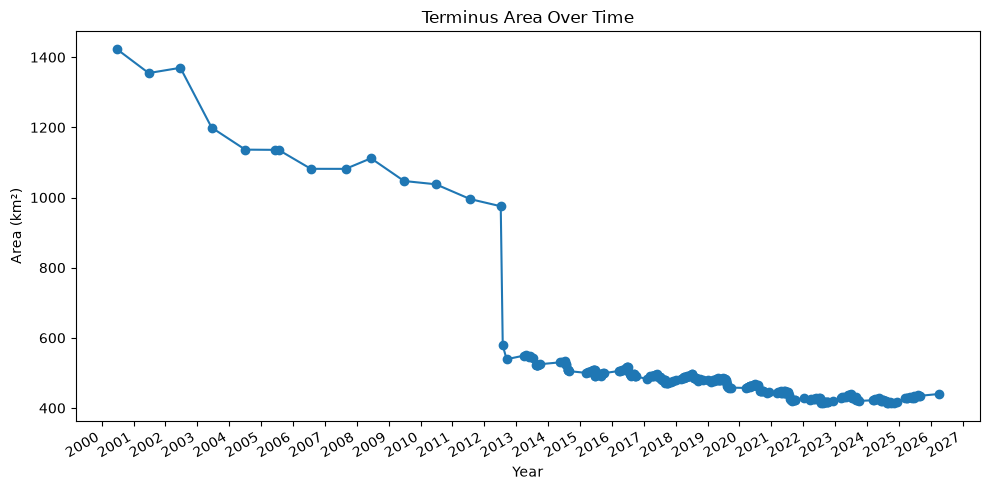

In [23]:
import matplotlib.dates as mdates

result["date"] = pd.to_datetime(result["date"])
result = result.sort_values("date")

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(result["date"], result["area_km2"], marker="o", linewidth=1.5)

ax.set_title("Terminus Area Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Area (km²)")

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.autofmt_xdate()
fig.tight_layout()
plt.savefig('/Users/cjense/Desktop/phd/data/termini/ZI/ZI_terminus_area_km2.png', dpi=300)
plt.show()

<Axes: >

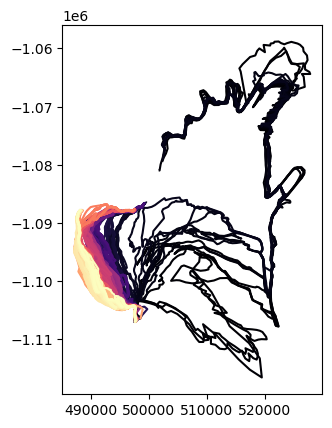

In [ ]:

result.geometry.plot(cmap='magma')